# Housing Analysis 

In [313]:
## Packages
import os
import pandas as pd 
import numpy as nu 
import matplotlib.pyplot as plt 

## Data collection

In [314]:
path = os.getcwd()
print(path)

c:\Users\USER\Desktop\Codes\Data\Q_housing


In [315]:
data = pd.read_csv(f"{path}/quebec_housing_sales_v2.csv") 

In [316]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       5000 non-null   int64  
 1   city              5000 non-null   object 
 2   neighborhood      5000 non-null   object 
 3   property_type     5000 non-null   object 
 4   bedrooms          5000 non-null   int64  
 5   bathrooms         5000 non-null   int64  
 6   living_area_sqft  5000 non-null   int64  
 7   lot_size_sqft     3789 non-null   float64
 8   year_built        5000 non-null   int64  
 9   renovation_year   1592 non-null   float64
 10  garage            5000 non-null   object 
 11  basement          5000 non-null   object 
 12  sale_year         5000 non-null   int64  
 13  sale_price        5000 non-null   int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 547.0+ KB


In [317]:
data.describe()

,property_id,bedrooms,bathrooms,living_area_sqft,lot_size_sqft,year_built,renovation_year,sale_year,sale_price
count,5000.000000,5000.000000,5000.000000,5000.000000,3789.000000,5000.000000,1592.000000,5000.000000,5.000000e+03
mean,2500.500000,3.488200,2.325800,1313.693800,6257.154658,1983.074000,2015.054020,2023.411600,4.802140e+05
std,1443.520003,1.357435,0.968009,472.106052,2811.434500,26.483028,5.764461,1.332119,1.771254e+05
min,1.000000,1.000000,1.000000,469.000000,1570.000000,1900.000000,2005.000000,2021.000000,1.140000e+05
25%,1250.750000,2.000000,2.000000,915.000000,4086.000000,1966.000000,2010.000000,2022.000000,3.527500e+05
50%,2500.500000,3.000000,2.000000,1273.000000,5767.000000,1985.000000,2015.000000,2024.000000,4.530000e+05
75%,3750.250000,4.000000,3.000000,1650.000000,8005.000000,2004.000000,2020.000000,2025.000000,5.840000e+05
max,5000.000000,8.000000,6.000000,2967.000000,14834.000000,2023.000000,2025.000000,2025.000000,1.425000e+06


In [318]:
data.head()

,property_id,city,neighborhood,property_type,bedrooms,bathrooms,living_area_sqft,lot_size_sqft,year_built,renovation_year,garage,basement,sale_year,sale_price
0,1,Châteauguay,Centre-Ville,Townhouse,3,2,1160,2304.0,2022,NaN,Yes,No,2024,326000
1,2,Trois-Rivières,Cap-de-la-Madeleine,Duplex,4,4,1807,5869.0,2006,2024.0,No,Yes,2025,444000
2,3,Lévis,Charny,Townhouse,3,1,803,3387.0,1989,NaN,Yes,Yes,2025,273000
3,4,Laval,Fabreville,Single Family,3,3,1083,11417.0,1972,2016.0,Yes,Yes,2023,465000
4,5,Longueuil,Greenfield Park,Condo,2,2,714,NaN,1997,2010.0,Yes,No,2022,371000


## Data Cleaning

In [319]:
data['property_type'].unique()

array(['Townhouse', 'Duplex', 'Single Family', 'Condo', 'Bungalow',
       'Triplex'], dtype=object)

In [320]:
data[data['lot_size_sqft'].isna()].head()

,property_id,city,neighborhood,property_type,bedrooms,bathrooms,living_area_sqft,lot_size_sqft,year_built,renovation_year,garage,basement,sale_year,sale_price
4,5,Longueuil,Greenfield Park,Condo,2,2,714,NaN,1997,2010.0,Yes,No,2022,371000
10,11,Longueuil,Le Vieux-Longueuil,Condo,1,2,768,NaN,2014,NaN,Yes,No,2025,523000
13,14,Repentigny,Le Gardeur,Condo,1,1,991,NaN,2002,NaN,No,No,2024,534000
15,16,Candiac,Candiac Centre,Condo,2,2,806,NaN,2010,NaN,No,No,2025,464000
16,17,Baie-Comeau,Baie-Comeau Centre,Condo,3,1,512,NaN,1984,NaN,Yes,No,2025,153000


In [321]:
data[data['renovation_year'].isna()].head()

,property_id,city,neighborhood,property_type,bedrooms,bathrooms,living_area_sqft,lot_size_sqft,year_built,renovation_year,garage,basement,sale_year,sale_price
0,1,Châteauguay,Centre-Ville,Townhouse,3,2,1160,2304.0,2022,NaN,Yes,No,2024,326000
2,3,Lévis,Charny,Townhouse,3,1,803,3387.0,1989,NaN,Yes,Yes,2025,273000
5,6,Victoriaville,Centre-Ville,Single Family,4,3,2081,5682.0,1967,NaN,Yes,Yes,2023,458000
6,7,Montréal,Outremont,Townhouse,3,3,1036,3343.0,1939,NaN,No,Yes,2023,383000
7,8,Sherbrooke,Lennoxville,Single Family,4,2,1767,4750.0,2007,NaN,Yes,Yes,2023,475000


In [322]:
data['city'].value_counts()

city
Montréal                      919
Québec                        529
Laval                         460
Longueuil                     394
Brossard                      244
Sherbrooke                    220
Gatineau                      207
Terrebonne                    174
Repentigny                    147
Trois-Rivières                137
Lévis                         124
Saint-Jean-sur-Richelieu      121
Saint-Jérôme                  117
Blainville                    112
Saguenay                       93
Mirabel                        90
Granby                         90
Drummondville                  89
Dollard-des-Ormeaux            82
Châteauguay                    81
Vaudreuil-Dorion               79
Boucherville                   72
Saint-Bruno-de-Montarville     57
Victoriaville                  56
Candiac                        55
Pointe-Claire                  51
Rimouski                       49
Alma                           36
Sept-Îles                      36
Val-d'Or 

## Data Analysis 

In [323]:
data = data.convert_dtypes()

In [324]:
data['lot_size_sqft'] = data['lot_size_sqft'].fillna(int(data['lot_size_sqft'].mean()))

In [325]:
data['renovation_year'] = data['renovation_year'].fillna(0)

In [326]:
data['sale_du'] = data['sale_year'] -  data['year_built'] 

In [327]:
data['sale_du']

0        2
1       19
2       36
3       51
4       25
        ..
4995    38
4996    12
4997    71
4998    30
4999    52
Name: sale_du, Length: 5000, dtype: Int64

## Data Visualization 

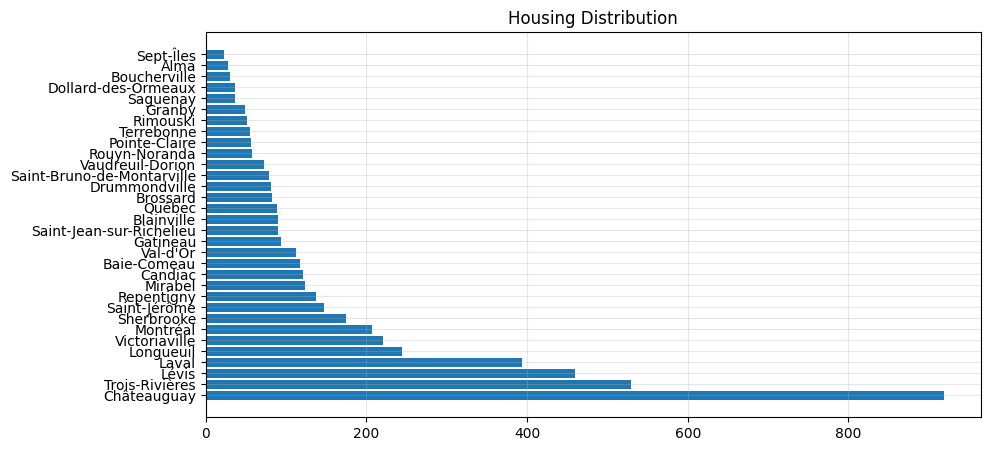

In [328]:
# Housing Distribution
plt.figure(figsize=(10,5))
plt.barh(data['city'].unique(), data['city'].value_counts())
plt.title('Housing Distribution')
plt.grid(True, alpha=0.3)
plt.show();

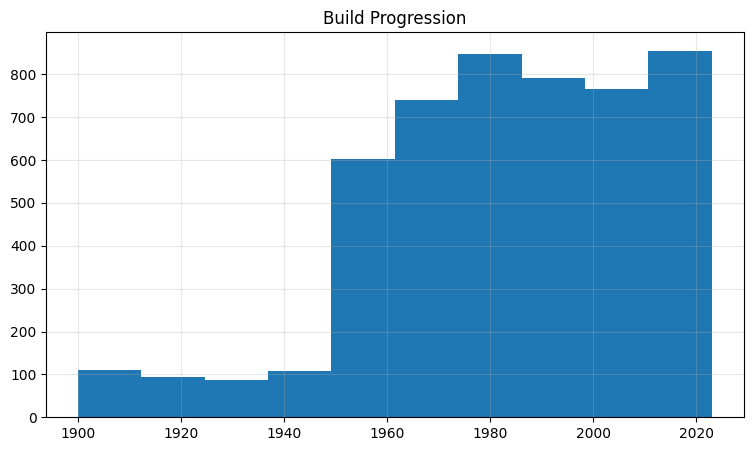

In [329]:
# Build progression
plt.figure(figsize=(9,5))
plt.hist(data['year_built'])
plt.title('Build Progression')
plt.grid(True, alpha=0.3)
plt.show();

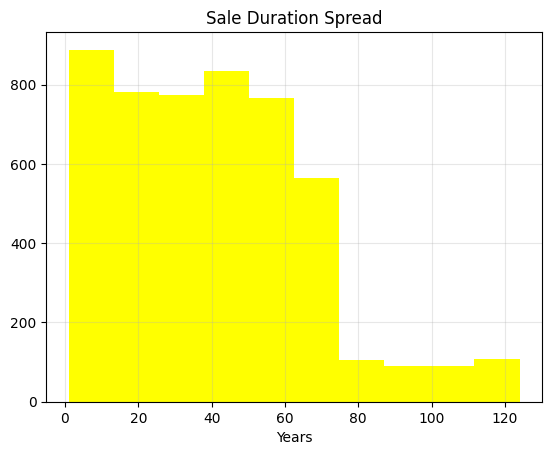

In [330]:
# Sale Duration
plt.hist(data['sale_du'], color='yellow')
plt.xlabel('Years')
plt.title('Sale Duration Spread')
plt.grid(True, alpha=0.3)
plt.show();

In [331]:
data['sale_price'].mean()

np.float64(480214.0)

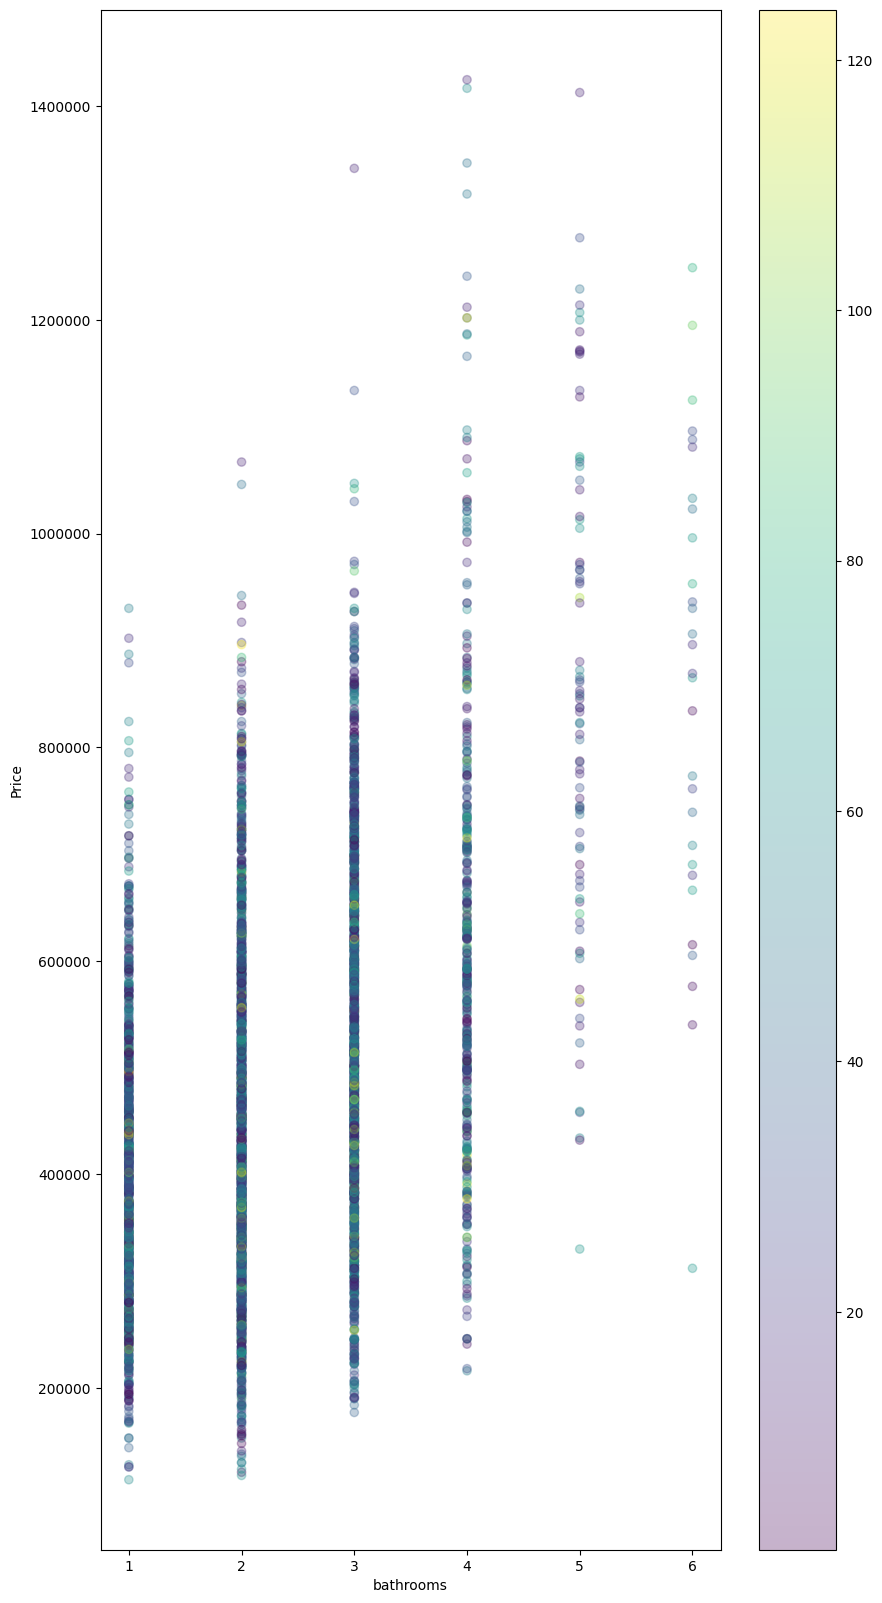

In [332]:
# Bathrooms
plt.figure(figsize=(10,20))
plt.scatter(data['bathrooms'], data['sale_price'], alpha=0.3, c=data['sale_du'])
plt.colorbar()
plt.xlabel('bathrooms')
plt.ylabel('Price')
plt.ticklabel_format(style='plain', axis='y') 
plt.title('')
plt.show();

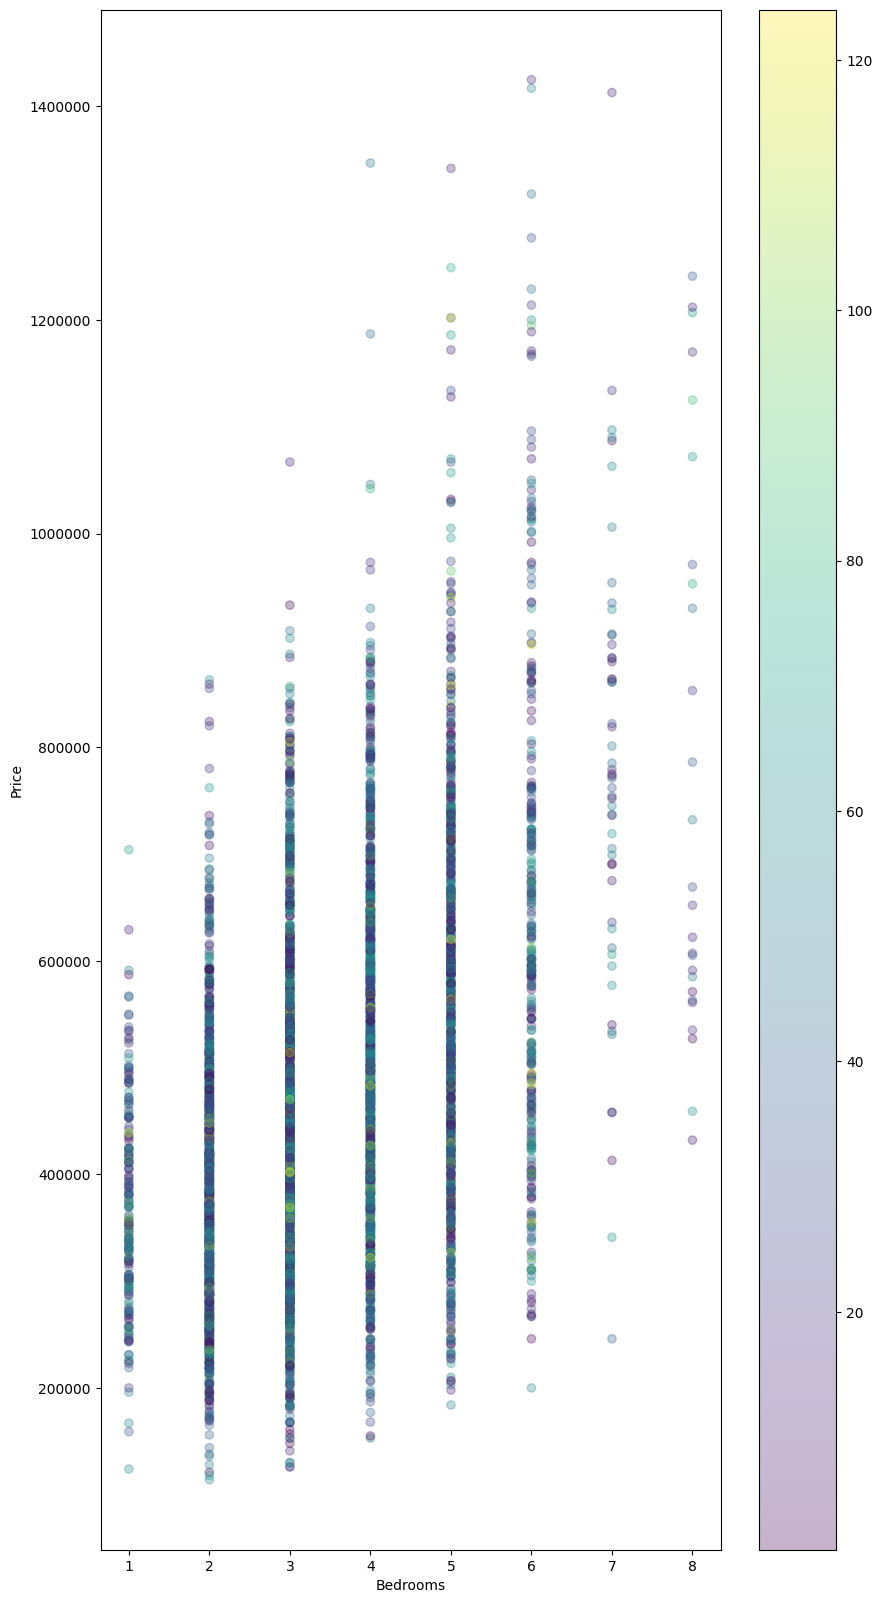

In [333]:
# Bedrooms
plt.figure(figsize=(10,20))
plt.scatter(data['bedrooms'], data['sale_price'], alpha=0.3, c=data['sale_du'])
plt.colorbar()
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.ticklabel_format(style='plain', axis='y') 
plt.title('')
plt.show();

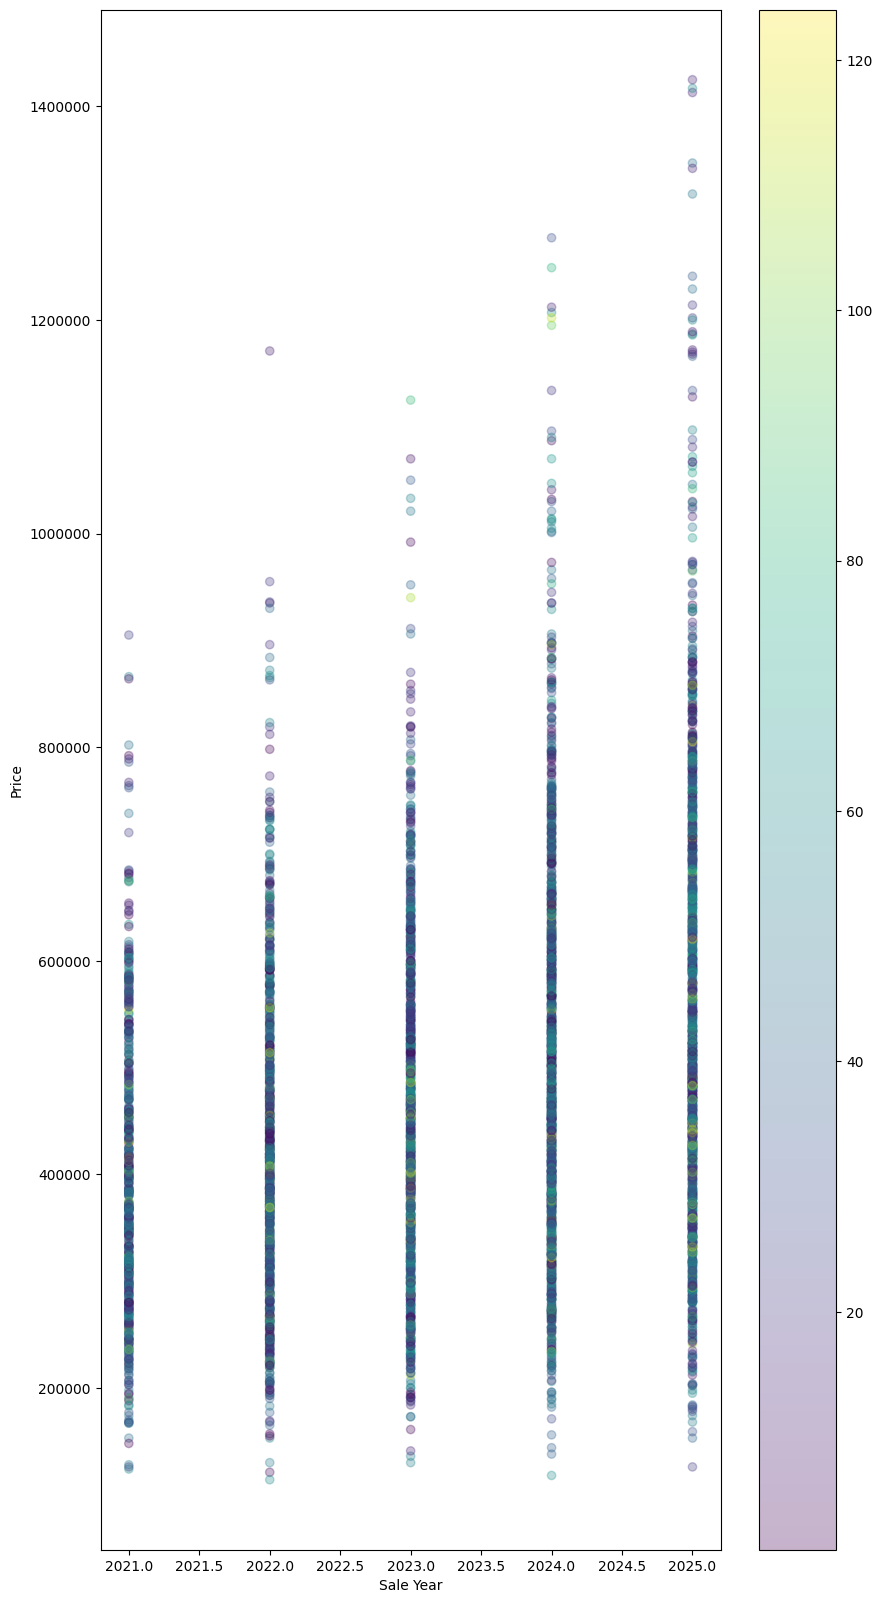

In [334]:
# Sale Year
plt.figure(figsize=(10,20))
plt.scatter(data['sale_year'], data['sale_price'], alpha=0.3, c=data['sale_du'])
plt.colorbar()
plt.xlabel('Sale Year')
plt.ylabel('Price')
plt.ticklabel_format(style='plain', axis='y') 
plt.title('')
plt.show();

In [335]:
#corr_data = data['bedrooms'], data['bathrooms'], data['living_area']

In [336]:
corr_matrix = data.drop(['city'], axis=1)

In [337]:
corr_matrix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   property_id       5000 non-null   Int64 
 1   neighborhood      5000 non-null   string
 2   property_type     5000 non-null   string
 3   bedrooms          5000 non-null   Int64 
 4   bathrooms         5000 non-null   Int64 
 5   living_area_sqft  5000 non-null   Int64 
 6   lot_size_sqft     5000 non-null   Int64 
 7   year_built        5000 non-null   Int64 
 8   renovation_year   5000 non-null   Int64 
 9   garage            5000 non-null   string
 10  basement          5000 non-null   string
 11  sale_year         5000 non-null   Int64 
 12  sale_price        5000 non-null   Int64 
 13  sale_du           5000 non-null   Int64 
dtypes: Int64(10), string(4)
memory usage: 595.8 KB


In [338]:
corr_fun = corr_matrix.corr()

ValueError: could not convert string to float: 'Centre-Ville'

In [ ]:
print(corr_matrix)

                  property_id  city  neighborhood  property_type  bedrooms  \
property_id               NaN   NaN           NaN            NaN       NaN   
city                      NaN   NaN           NaN            NaN       NaN   
neighborhood              NaN   NaN           NaN            NaN       NaN   
property_type             NaN   NaN           NaN            NaN       NaN   
bedrooms                  NaN   NaN           NaN            NaN       NaN   
bathrooms                 NaN   NaN           NaN            NaN       NaN   
living_area_sqft          NaN   NaN           NaN            NaN       NaN   
lot_size_sqft             NaN   NaN           NaN            NaN       NaN   
year_built                NaN   NaN           NaN            NaN       NaN   
renovation_year           NaN   NaN           NaN            NaN       NaN   
garage                    NaN   NaN           NaN            NaN       NaN   
basement                  NaN   NaN           NaN            NaN

In [ ]:
"""
data[data['city'] == 'Boucherville'] = data[data['city'] == 'boucherville']

data[data['city'] == 'Alma'] = data[data['city'] == 'alma']

data[data['city'] == 'Sept-Îles'] = data[data['city'] == 'sept-iles']

data[data['city'] == 'Rouyn-Noranda'] = data[data['city'] == 'rouyn-noranda']

data[data['city'] == 'Pointe-Claire'] = data[data['city'] == 'pointe-claire']

data[data['city'] == 'Terrebonne'] = data[data['city'] == 'terrebonne']

data[data['city'] == 'Rimouski'] = data[data['city'] == 'rimouski']

data[data['city'] == 'Granby'] = data[data['city'] == 'granby']

data[data['city'] == 'Saguenay'] = data[data['city'] == 'saguenay']

data[data['city'] == 'Dollard-des-Ormeaux'] = data[data['city'] == 'dollard-des-ormeaux']

data[data['city'] == 'Saint-Jean-sur-Richelieu'] = data[data['city'] == 'saint-jean-sur-richelieu']

data[data['city'] == 'Blainville'] = data[data['city'] == 'blainville']

data[data['city'] == 'Québec'] = data[data['city'] == 'quebec']

data[data['city'] == 'Brossard'] = data[data['city'] == 'brossard']

data[data['city'] == 'Drummondville'] = data[data['city'] == 'drummondville']

data[data['city'] == 'Saint-Bruno-de-Montarville'] = data[data['city'] == 'saint-bruno-de-montarville']

data[data['city'] == 'Vaudreuil-Dorion'] = data[data['city'] == 'vaudreuil-dorion']

data[data['city'] == 'Saint-Jérôme'] = data[data['city'] == 'saint-Jerome']

data[data['city'] == 'Repentigny'] = data[data['city'] == 'repentigny']

data[data['city'] == 'Mirabel'] = data[data['city'] == 'mirabel']

data[data['city'] == 'Candiac'] = data[data['city'] == 'candiac']

data[data['city'] == 'Baie-Comeau'] = data[data['city'] == 'baie-comeau']

data[data['city'] == "Val-d'Or"] = data[data['city'] == 'val-dOr']

data[data['city'] == "Gatineau"] = data[data['city'] == 'gatineau']

data[data['city'] == 'Châteauguay'] = data[data['city'] == 'chateauguay']

data[data['city'] == 'Trois-Rivières'] = data[data['city'] == 'trois-rivieres']

data[data['city'] == 'Lévis'] = data[data['city'] == 'levis']

data[data['city'] == 'Laval'] = data[data['city'] == 'laval']

data[data['city'] == 'Longueuil'] = data[data['city'] == 'longueuil']

data[data['city'] == 'Victoriaville'] = data[data['city'] == 'victoriaville']

data[data['city'] == 'Montréal'] = data[data['city'] == 'montreal']

data[data['city'] == 'Sherbrooke'] = data[data['city'] == 'sherbrooke']
"""

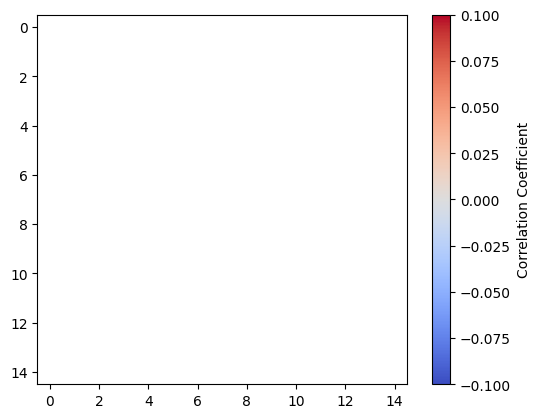

In [ ]:
fig, ax = plt.subplots()
plt.imshow(corr, cmap='coolwarm')
plt.colorbar(label = 'Correlation Coefficient')
plt.show();

## insights 

#### Review points
> Duration between year built(renovation impact) and sale year <br>
High population density <br>
Nighborhood pefrence <br>
Family size based on bedroon/bathroom <br>
What year experienced the highest number of houses built <br>
Factors influencing sale price <br>
issues to address <br>